# Reinforcement Learning

Some agent makes observations and takes actions within an environment. There are rewards within the environment, and the agent learns to take actions that have higher expected rewards

The rewards can be basically anything. Only negative rewards for taking wrong turns, only positive rewards for reaching a series of checkpoints, etc.

## Policy Gradients

The algorithm an agent uses to determine its actions is a *policy*

Example: a robot vacuum that moves forward with probability p, or randomly rotate left/right with probability 1-p. The rotation is random, between -r and +r. This is a *stochastic policy*. You want to maximize the amount of dust it picks up in some timeframe, but there are only two parameters to tweak, p and r. 
- Policy search: try every possible value of (p, r)
- Genetic algorithms: Randomly generate some number of policies, try them, kill the worst 80 policies and have the 20 survivors produce 4 offspring where an offspring is just a copy of the parent with a little variation.
- Policy gradient algorithms: evaluate the gradient of the policy and tweak its values

### Gymnasium Library

You need a simulated environment to train RL agents

In [67]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="rgb_array", max_episode_steps=1000)

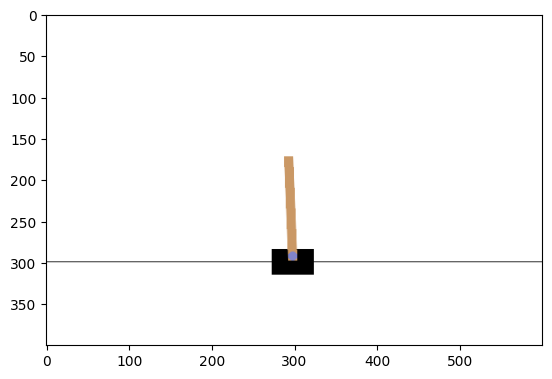

In [68]:
import matplotlib.pyplot as plt
obs, info = env.reset(seed=22)
plt.imshow(env.render())

In [69]:
env.action_space
# Possible actions are integers 0 and 1 - meaning left or right

Discrete(2)

In [70]:
obs
# here: position, velocity, pole angle, pole angular velocity

array([-0.01336531, -0.03007046, -0.04114416,  0.01531917], dtype=float32)

In [71]:
action = 0
obs, reward, done, truncated, info = env.step(action)
obs, reward

(array([-0.01396672, -0.22457895, -0.04083778,  0.294742  ], dtype=float32),
 1.0)

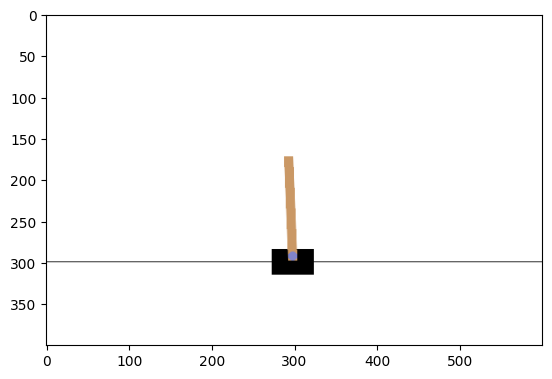

In [72]:
plt.imshow(env.render())

- Obs - the new state 
- Reward - you get 1.0 at every step, the only goal is to keep the cart running
- Done: true when episode is over
- Truncated: true when an episode is interrupted (if you set a max number of steps, here, 1000)

In [73]:
def basic_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

totals = []
for episode in range(500):
    total_rewards = 0
    obs, inf = env.reset(seed=episode)
    while True:
        action = basic_policy(obs)
        obs, rew, done, trunc, info = env.step(action)
        total_rewards+=rew
        if done or trunc:
            break
    totals.append(total_rewards)

In [76]:
import numpy as np
np.mean(totals), np.std(totals), min(totals), max(totals)

(np.float64(41.698), np.float64(8.389445512070509), 24.0, 63.0)

### Neural Network Policies

We need to make a network that takes in the obs state and has one output neuron (for 0 or 1 prob). If the output probability is 70% 1, then you still sample with 30% prob 0 so the network can explore new actions while exploiting the ones that work well

There is no hidden state here but if there was it may be worth keeping info over time

In [82]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,5), nn.ReLU(),
            nn.Linear(5, 1) # no sigmoid - logits instead of probabilities
        )
    
    def forward(self, state):
        return self.net(state)
    
def choose_action(model, obs):
    state = torch.as_tensor(obs)
    logit = model(state)
    dist = torch.distributions.Bernoulli(logits=logit)
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return int(action.item()), log_prob

### Evaluating Actions

We don't know what the best action is at every step, so assigning credit to an action is more difficult than in past models

Common strategy: evaluate an action based on the sum of all rewards following that action, applying some discount factor gamma at every step (so it gets less credit for a reward 1000 steps away)

In [85]:
def compute_returns(rewards, discount_factor):
    returns = rewards[:]
    for step in range(len(returns) - 1, 0, -1):
        returns[step - 1] += returns[step] * discount_factor
    return torch.tensor(returns)

compute_returns([10, 0, -50], .8)
# generally, discount factor btwn .95 and .999

tensor([-22., -40., -50.])

### Solving CartPole with Policy Gradients

REINFORCE algorithm (for PG):
1) Let the neural network play the game for 1 episode, record the rewards and log probs
2) Compute each actions return
3) If an action has positive return, do it more in the future, if it has negative return, do it less

Minimize the REINFORCE loss:
$$ \mathcal{L}(\theta) = - \sum_t \log \pi_{\theta} (a_t | s_t) \cdot r_t $$
- $\pi_{\theta} (a_t | s_t)$ represents the policy networks estimated probability for some action a_t, given state s_t, 
- and r_t is the observed return of the action

In [89]:
def run_episode(model, env, seed=None):
    log_probs, rewards = [], []
    obs, info = env.reset(seed=seed)
    while True: 
        action, log_prob = choose_action(model, obs)
        obs, reward, done, truncated, _info = env.step(action)
        log_probs.append(log_prob)
        rewards.append(reward)
        if done or truncated:
            return log_probs, rewards
        
def train_reinforce(model, optimizer, env, n_episodes, discount_factor):
    for episode in range(n_episodes):
        seed = torch.randint(0, 2**32, size=()).item()
        log_probs, rewards = run_episode(model, env, seed=seed) # run the episode
        returns = compute_returns(rewards, discount_factor) 
        std_returns = (returns - returns.mean()) / (returns.std() + 1e-7) # standardize the returns for stable training
        losses = [-logp * rt for logp, rt in zip(log_probs, std_returns)] # the REINFORCE loss
        loss = torch.cat(losses).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"\rEpisode {episode + 1}, Reward: {sum(rewards):.2f}", end=" ")

In [94]:
torch.manual_seed(42)
model = PolicyNetwork()
optimizer = torch.optim.NAdam(model.parameters(), lr=0.06)
train_reinforce(model, optimizer, env, n_episodes=500, discount_factor=0.99)

Episode 500, Reward: 1000.00 

For better performance you can also inject human biases into the agent for performance - like adding a negative reward that scales with the pole's angle

REINFORCE works well for this example, but its too unstable generally - can forget everything over time. If it only sees vertical poles, itll forget what to do with slightly nonvertical poles after a while.

## Value-Based Methods

PG algorithms directly try and find the policy with the best rewards

Value based methods try to estimate the value, or expected return, of some state 

### Markov Decision Processes
- Markov chains: stochastic processes without memory

P(going from state s to s') -> depends only on (s, s'), not on anything else in the past

Markov decision processes: at each step, an agent can choose one of many possible actions. Transition probabilities DEPEND on the action chosen
- Some state transitions get a reward
- Agent wants to maximize reward over time

**Bellman Optimality**
- Estimate the optimal state value for any state s - the sum of all discounted future rewards, starting from state s
- If the agent acts optimally, optimal value of current state = avg reward after 1 optimal action + E(optimal value of all possible next states)

$$ V^*(s) = \max_a \sum_{s'}T(s,a,s')[R(s,a,s') + \gamma \cdot V^*(s')] $$
- $T(s,a,s')$ = transition probability from state s -> state s' (given agent chose action a)
- $R(s,a,s')$ = reward for going from s to s', given action a was chosen
- gamma is the discount factor


This gives you a value iteration algorithm - start by setting all state value estimates to 0, and iterate through 

$$ V_{k+1}(s) = \max_a \sum_{s'}T(s,a,s')[R(s,a,s') + \gamma \cdot V^*(s')]$$

for all s - V_k is the estimated value of state s at the k'th iteration

This gives the optimal state values, but not the optimal policy. So theres another algorithm to estimate optimal state-action values (Q-values, quality)

The optimal q value for state action pair (s,a) is the sum of all discounted future rewards the agent can expect starting from state s, choosing action a
$$ Q_{k+1}(s, a) = \max_a \sum_{s'}T(s,a,s')[R(s,a,s') + \gamma \cdot \max_{a'} Q_{k}(s', a')]$$



### Temporal Difference Learning
- Usually you have no idea (or the agent has no idea) what all the probabilities and rewards are before going through all the actions and states, many times to get a good probability estimate, once to know the reward

Temporal Difference (TD) algorithm : assume only the agent knows what actions and states there are, nothing more
- Use an exploration policy to explore the markov decision processes, and update the state values based on observations

$$V_{k+1}(s) = (1-\alpha)V_k(s) + \alpha (r + \gamma \cdot V_k(s'))$$
- alpha is the learning rate
- $(r + \gamma \cdot V_k(s'))$ is the TD target

Similar to SGD - reduce alpha over time to get better Q values

### Q-Learning

Watch an agent play, and improve Q value estimates until you know enough to choose actions with the highest q values